## Homework 12

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.


### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?

In [72]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]


[ANSWER] Number of images for class 0: 2220
[ANSWER] Number of images for class 1: 2250

Visualizing a few image examples for Class 0:


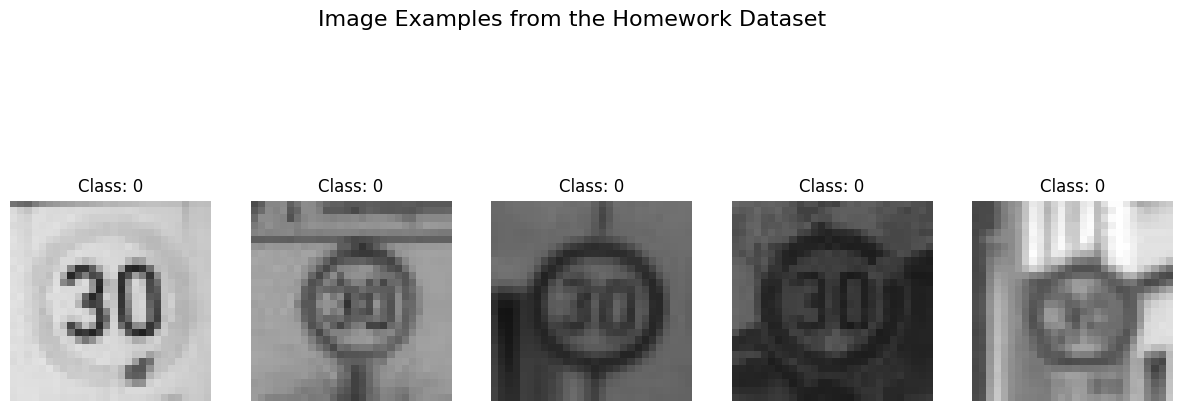


Visualizing a few image examples for Class 1:


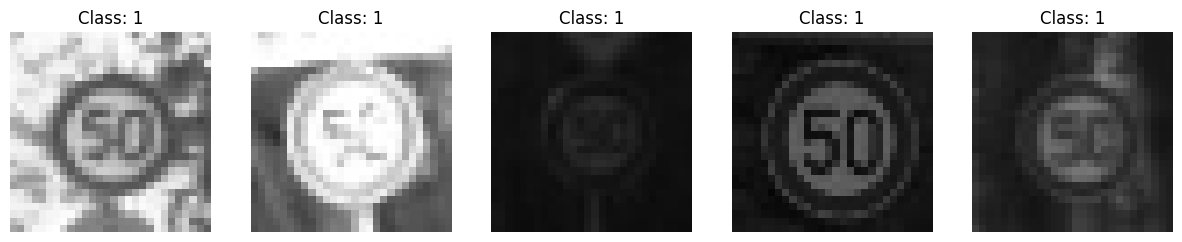


Shape of the prepared data: (4470, 784)


In [73]:

folder = '../data/subset_homework'
# Load images and labels
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

# ANSWER TO QUESTION 1: How many images are in each class?
print(f"\n[ANSWER] Number of images for class 0: {len(images_0)}")
print(f"[ANSWER] Number of images for class 1: {len(images_1)}")

# Visualize examples for Class 0
print("\nVisualizing a few image examples for Class 0:")

plt.suptitle('Image Examples from the Homework Dataset', fontsize=16)
for cnt, idx in enumerate(np.random.randint(0, len(images_0), 5)):
    plt.subplot(1, 5, cnt + 1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Class: {labels_0[idx]}')
    plt.axis('off')
plt.show()

# Visualize examples for Class 1
print("\nVisualizing a few image examples for Class 1:")

# Note: No suptitle here to avoid repetition, but you can add it if you like.
for cnt, idx in enumerate(np.random.randint(0, len(images_1), 5)):
    plt.subplot(1, 5, cnt + 1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Class: {labels_1[idx]}')
    plt.axis('off')
plt.show()

# --- Data Preparation ---
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

# Flatten and normalize the images
pixels = np.array([image.flatten() for image in images]) / 255.0
print(f'\nShape of the prepared data: {pixels.shape}')

In [74]:
# Single-neuron model architecture
inputs_base = Input(shape=(pixels.shape[1],))
outputs_base = Dense(1, activation="linear")(inputs_base)
model_base = Model(inputs=inputs_base, outputs=outputs_base)
model_base.compile(optimizer='adam', loss='mean_squared_error')
print("Base model architecture:")
model_base.summary()

# Training
history_base = model_base.fit(pixels, labels, epochs=15, batch_size=32, verbose=0)

# Accuracy evaluation
predictions_base = model_base.predict(pixels).squeeze()
predictions_base_class = predictions_base > 0.5
accuracy_base = np.mean(predictions_base_class == labels)


print(f"\n[ANSWER] Accuracy achieved with the single-neuron model: {accuracy_base:.2%}\n")

Base model architecture:


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step

[ANSWER] Accuracy achieved with the single-neuron model: 94.56%



### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?

Improved model architecture:


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 56)             │        43,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,017 (171.94 KB)

 Trainable params: 44,017 (171.94 KB)

 Non-trainable params: 0 (0.00 B)


[ANSWER] Maximum accuracy achieved with the improved model: 98.01%

Visualizing the performance of the improved model:
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step


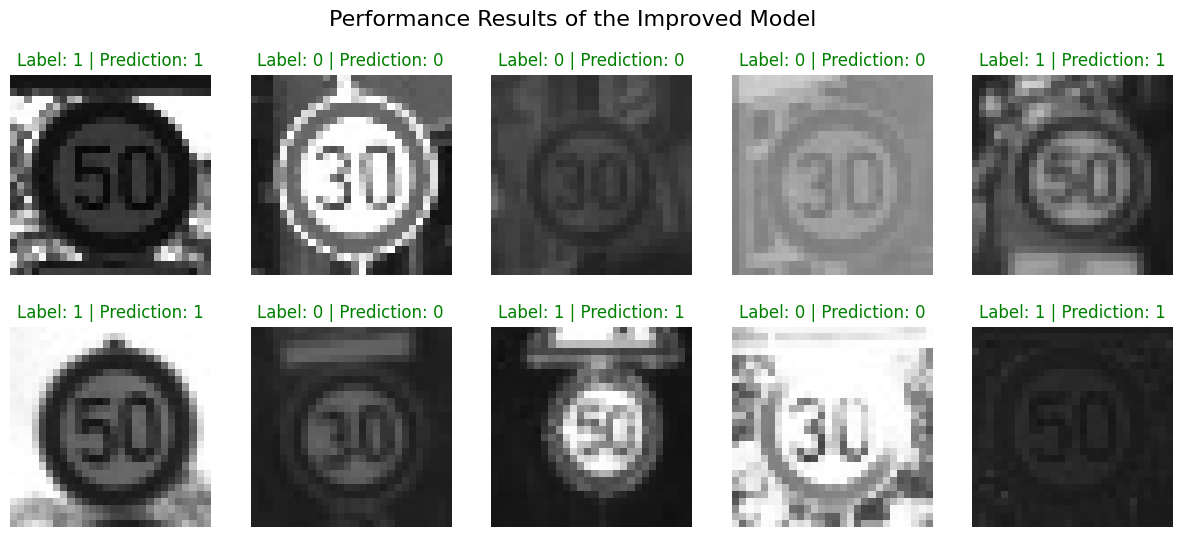

In [75]:
# Improved model architecture
inputs_improved = Input(shape=(pixels.shape[1],))
# Add a hidden layer with 56 neurons
# hidden_layer = Dense(32, activation='relu')(inputs_improved)
hidden_layer = Dense(56, activation='linear')(inputs_improved)
# Output layer with 'sigmoid' activation for classification
outputs_improved = Dense(1, activation='sigmoid')(hidden_layer)
model_improved = Model(inputs=inputs_improved, outputs=outputs_improved)

# Compile with 'binary_crossentropy' loss, which is better suited for this task
model_improved.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Improved model architecture:")
model_improved.summary()

# Training
history_improved = model_improved.fit(pixels, labels, epochs=25, batch_size=32, verbose=0)

# Accuracy evaluation
loss_improved, accuracy_improved = model_improved.evaluate(pixels, labels, verbose=0)


print(f"\n[ANSWER] Maximum accuracy achieved with the improved model: {accuracy_improved:.2%}")


# Visualize the results of the improved model
print("\nVisualizing the performance of the improved model:")
predictions_improved = model_improved.predict(pixels).squeeze()
predictions_improved_class = predictions_improved > 0.5


plt.suptitle('Performance Results of the Improved Model', fontsize=16)
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2, 5, cnt + 1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    title_color = 'green' if labels[idx] == predictions_improved_class[idx] else 'red'
    plt.title(f'Label: {labels[idx]} | Prediction: {int(predictions_improved_class[idx])}', color=title_color)
    plt.axis('off')
plt.show()